In [1]:
%load_ext autoreload
%autoreload 2

# **Análisis Exploratorio de Datos** (EDA)

---

In [2]:
from data import EDA, STAGES_LABELS
import plots as plots
import metrics as metrics

c:\Users\agust\anaconda3\envs\pf_ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## El Dataset

Se compone de datos de 47 pacientes (BidslabXX) sanos con grabaciones de entre 3 a 7 noches de (1) la frecuencia cardiaca instantánea (IHR) y (2) 3 ejes de acelerometría medidos por un Apple Watch con un total de 253 noches de datos. Cada época (lapsos de 30 segundos) vienen etiquetados por un experto (*expert_label*) y el dispotitivo "Dreem 2 Headband" (*dreem_label*), un monitor de sueño portátil.

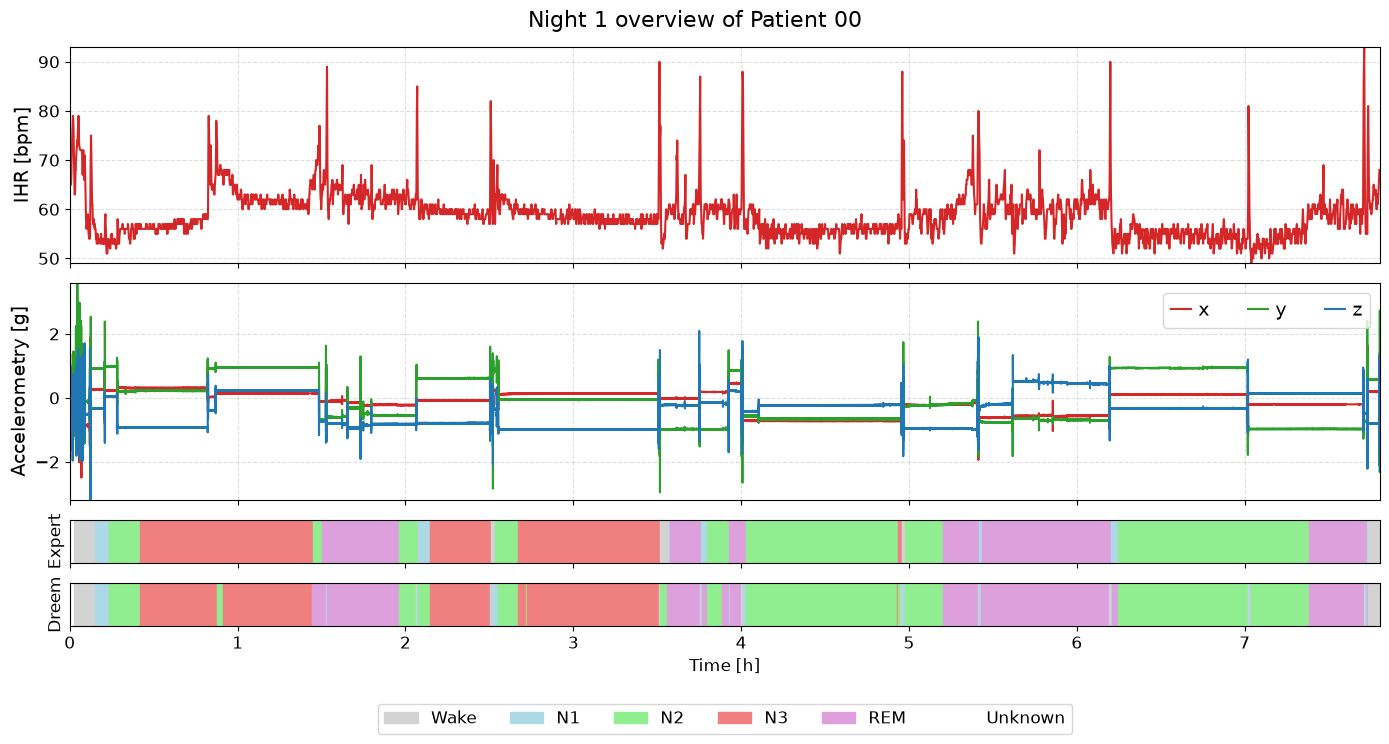

In [3]:
patient, night = 0, 1
night_data = EDA.load_night(patient, night)
plots.night_overview(night_data, patient, night)

Encontramos noches con datos inconsistentes y/o mal condicionados como por ejemplo el siguiente en el que los timestamps indican una duración de $\sim30$ horas, por lo que debimos analizar la calidad de cada noche.

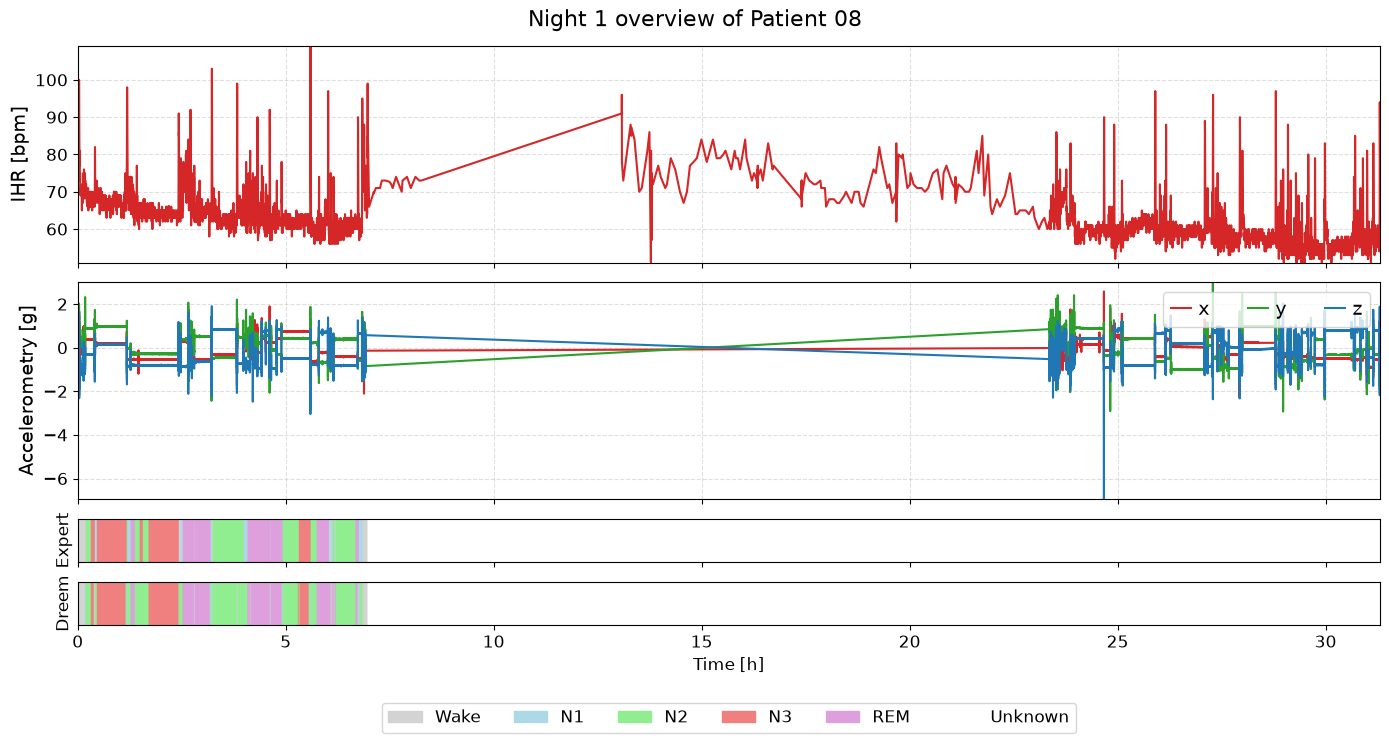

In [4]:
patient, night = 8, 1
night_data = EDA.load_night(patient, night)
plots.night_overview(night_data, patient, night)

`EDA.quality_report()` recorre las 253 noches y calcula, para cada una, métricas de calidad de señal:

- **Gaps temporales** en `hr.csv` y `motion.csv`: intervalos entre muestras consecutivas mayores a $\texttt{GAP\_THRESHOLD\_S} = 60s$, que indican períodos sin medición (el dispositivo interpola linealmente los valores faltantes en ese rango).
- **Duración total** (`hr_span_h`): horas que abarca la señal de `hr.csv`. Una noche dura $\approx$ 8h; valores muy por encima indican que el registro se extiende más allá de la ventana etiquetada (ese exceso se trunca al construir el dataset). Es una métrica informativa, no un criterio de descarte.
- **Valores NaN** (`hr_nan_count`, `motion_nan_count`): filas con datos faltantes en cada señal.
- **Acelerometría inválida**: fracción de muestras donde $|\sqrt{x^2+y^2+z^2} - 1| > \texttt{ACC\_TOL} = 0.5g$. En reposo, la norma del vector de aceleración debería ser exactamente $1g$ (gravedad); sin embargo, desviaciones grandes también ocurren por movimiento real del cuerpo, por lo que no se usa como criterio de descarte.
- **IHR inválido**: muestras con $\texttt{hr <= 0}$ ó $\texttt{hr > 200 bpm}$ (excluyendo los bordes de la grabación).

A partir de estas métricas definimos la **ventana válida** de cada noche: la intersección entre la ventana etiquetada $[\texttt{recStart},\ \texttt{recStart} + \texttt{label\_span\_s}]$ y el rango real de señal de `hr.csv` $[\texttt{hr\_start},\ \texttt{hr\_end}]$. De ahí surgen tres métricas de desajuste:

- **`leading_trunc_s`**: $\max(0,\ \texttt{hr\_start} - \texttt{recStart})$ — la señal empieza después del inicio de las labels.
- **`trailing_trunc_s`**: $\max(0,\ \texttt{label\_end} - \texttt{hr\_end})$ — la señal termina antes del fin de las labels.
- **`internal_gap_s`**: suma de gaps de `hr.csv` que caen dentro de la ventana válida — discontinuidades en medio de la secuencia nocturna.

**Criterio para marcar noches como problemáticas**: los desajustes en los extremos y los gaps internos se evalúan con umbrales separados porque tienen distinto impacto sobre el modelo:

1. **Extremos** (`leading_trunc_s`, `trailing_trunc_s`): si son menores a `EDGE_TRUNC_THRESHOLD_S = 1h`, la noche se *conserva* — al construir el dataset se truncan las epochs fuera de la ventana válida descartando sólo esa fracción de datos. Si superan ese umbral, la noche se marca como problemática.
2. **Gaps internos** (`internal_gap_s`): rompen la continuidad temporal de la secuencia, lo cual es especialmente problemático para modelos recurrentes. Criterio estricto: se marca como problemática si `internal_gap_s > INTERNAL_GAP_THRESHOLD_S = 10min`.

La lista con los valores de cada noche problemática se guarda en `analysis/problematic_nights.json`. La decisión de descartar o reparar cada noche (ej. colapsar gaps con timestamps corruptos) se realiza al construir el dataset.

In [5]:
df_quality = EDA.quality_report()

Paciente 68 - Noche 4: 100%|██████████| 253/253 [03:32<00:00,  1.19it/s]


In [6]:
problematic_nights = EDA.problematic_nights(df_quality)

print(f'Noches problemáticas: {len(problematic_nights)} / {len(df_quality)} ({100*len(problematic_nights)/len(df_quality):.1f}%)')

Noches problemáticas: 32 / 253 (12.6%)


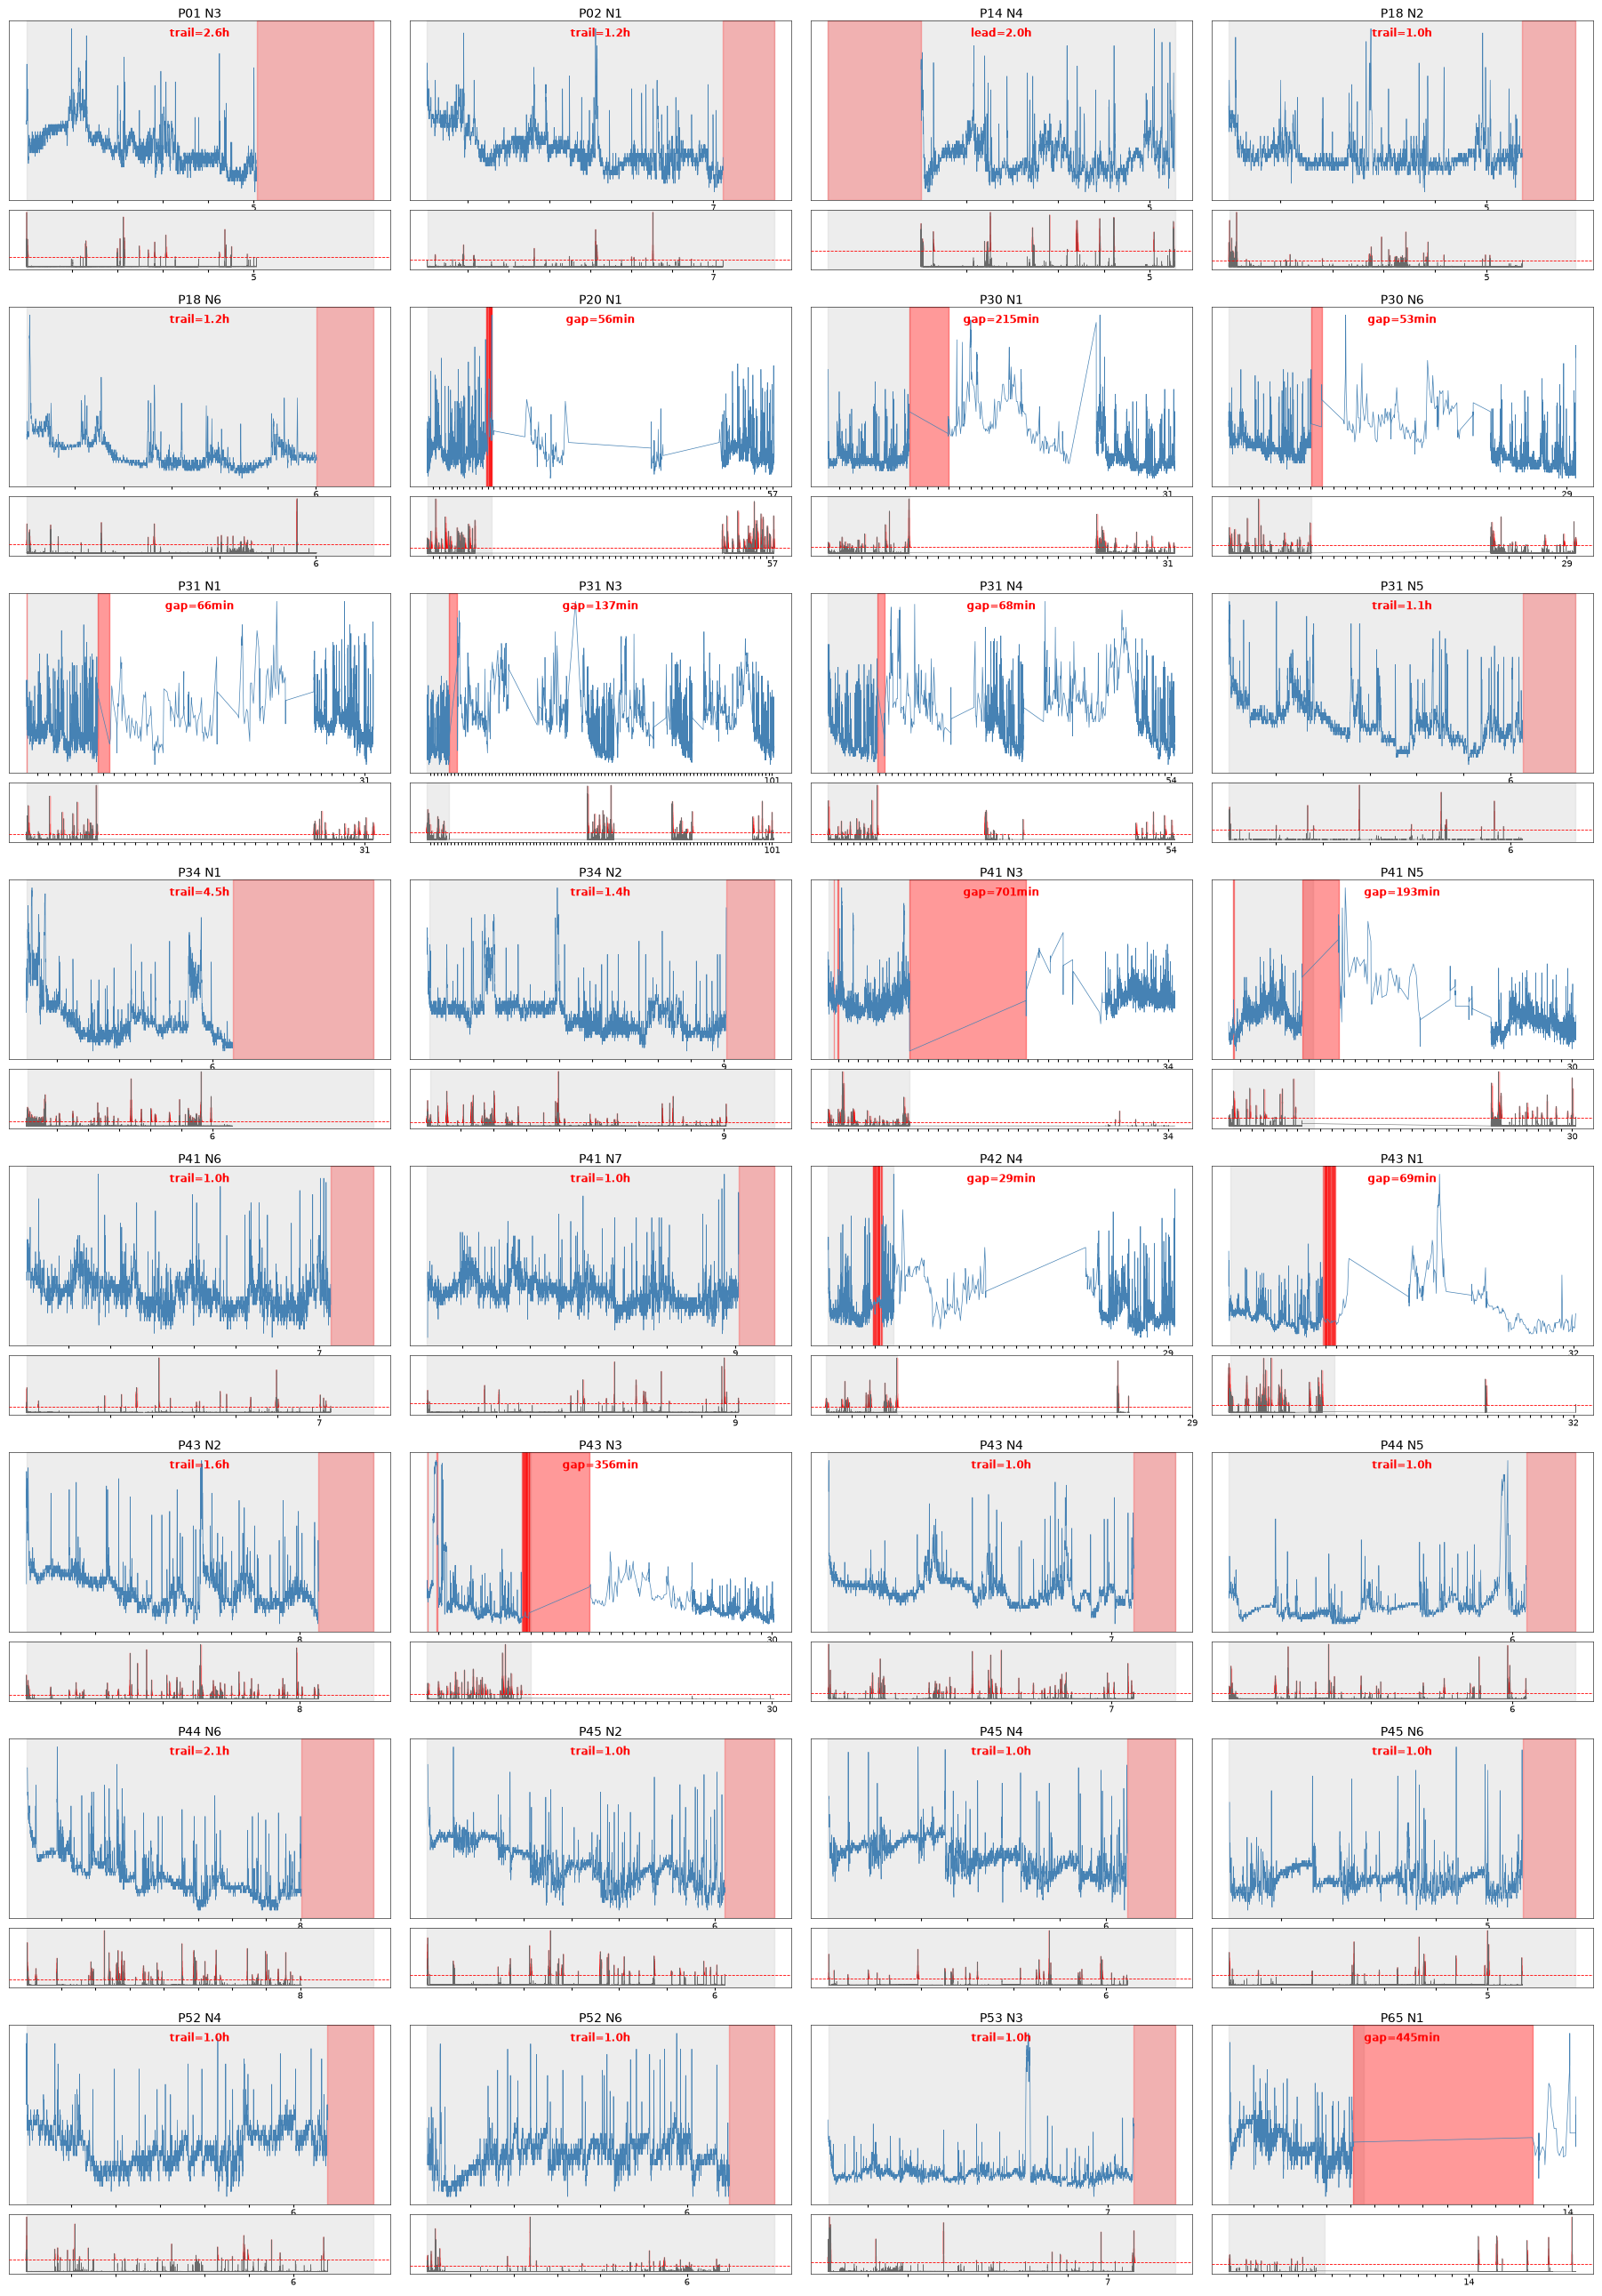

In [7]:
plots.problematic_nights_overview()

### Distribución de Etapas de Sueño

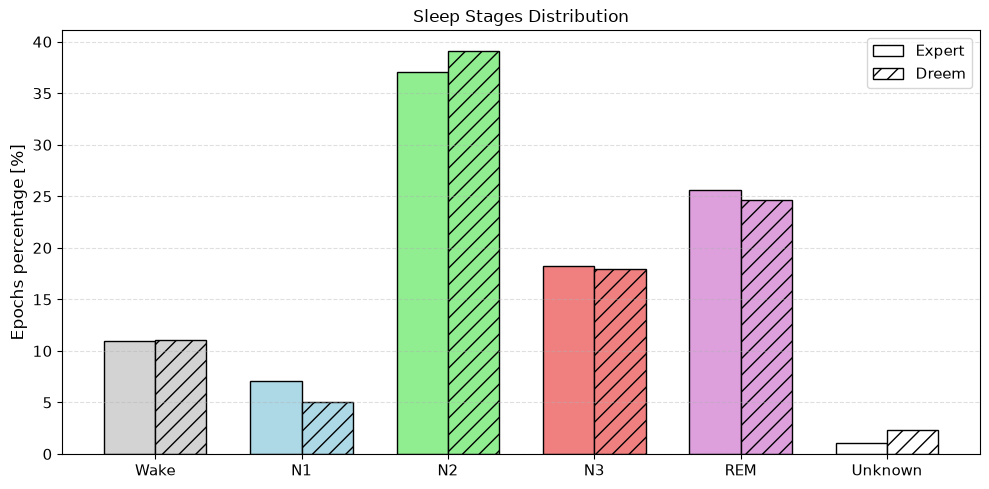

In [8]:
distributions = EDA.class_distribution()
plots.class_distribution(distributions)

### Labels "Expert" vs "Dreem"

**Cohen's Kappa** mide el *acuerdo* entre dos clasificadores (en este caso, el etiquetado del experto y el del dispositivo Dreem) corrigiendo por el acuerdo que se esperaría por azar dado el desbalance de clases (Cohen, 1960). Se define como:

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

donde:
- $p_o$ es la **proporción observada de acuerdo** (accuracy): fracción de epochs donde ambos etiquetados coinciden.
- $p_e$ es la **proporción de acuerdo esperada por azar**, calculada a partir de las distribuciones marginales de cada clasificador: $p_e = \sum_k \frac{n_{k\cdot} \cdot n_{\cdot k}}{n^2}$, con $n_{k\cdot}$ y $n_{\cdot k}$ las marginales de fila/columna de la matriz de confusión y $n$ el total de epochs.

**Valores que puede tomar:**
- $\kappa = 1$: acuerdo perfecto.
- $\kappa = 0$: el acuerdo observado es igual al esperado por azar (no hay acuerdo más allá del azar).
- $\kappa < 0$: el acuerdo es peor que el azar (desacuerdo sistemático).
- En general $-1 \le \kappa \le 1$.

**Interpretación habitual [(Landis & Koch, 1977)](http://doi.org/10.2307/2529310):** $<0$ sin acuerdo, $0$–$0.2$ leve, $0.2$–$0.4$ aceptable, $0.4$–$0.6$ moderado, $0.6$–$0.8$ sustancial, $0.8$–$1$ casi perfecto.

Además del valor global, se calcula $\kappa$ **por clase** mediante un esquema one-vs-rest: para cada etapa $k$ se binariza el problema (¿es clase $k$ o no?) y se computa $\kappa$ sobre esa matriz de confusión 2x2, lo que permite identificar en qué etapas específicas el experto y Dreem difieren más.

In [9]:
expert, dreem = EDA.all_labels()
kappa_global = metrics.cohen_kappa(expert, dreem)
kappa_per_class = metrics.cohen_kappa_per_class(expert, dreem)

labels = ['K (global)'] + [f'K ({stage})' for stage in STAGES_LABELS.values()]
label_width = max(len(l) for l in labels)

print(f'{labels[0]:<{label_width}} = {kappa_global:.4f}')
for label, k in zip(labels[1:], kappa_per_class):
    print(f'{label:<{label_width}} = {k:.4f}')

K (global) = 0.0585
K (Wake)   = 0.0096
K (N1)     = 0.0169
K (N2)     = 0.0530
K (N3)     = 0.1228
K (REM)    = 0.0554
K (Unkown) = 0.0297


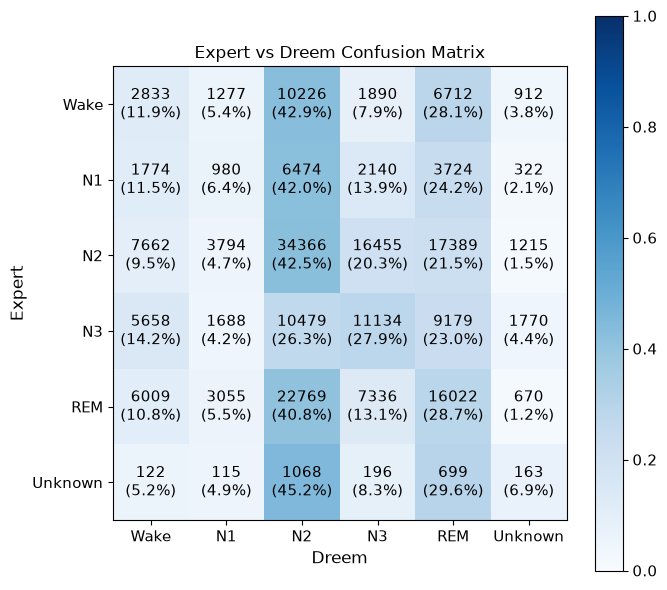

In [10]:
cm = metrics.confusion_matrix(expert, dreem)
plots.confusion_matrix(cm)

## 2 Enfoques Posibles para definir la **Secuencia**

Para procesar la secuencia de pasos temporales, debemos definir cuál es este paso temporal.

- **Intra-epoch**: el paso temporal es cada muestra dentro de una época (lapso de 30 segundos). Cada época se clasifica de forma independiente.
- **Inter-epoch**: el paso temporal es cada época completa. El modelo mira a lo largo de la noche.